In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,2013-01-09,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,2011-08-07,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,2014-09-28,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,2013-10-26,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,2014-11-27,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,2014-05-19,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,2011-08-07,Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,2012-01-11,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,2013-11-19,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51370 non-null  int64  
 1   Order ID        51370 non-null  str    
 2   Order Date      51370 non-null  str    
 3   Ship Date       51370 non-null  str    
 4   Ship Mode       51370 non-null  str    
 5   Customer ID     51370 non-null  str    
 6   Customer Name   51336 non-null  str    
 7   Segment         51370 non-null  str    
 8   City            51351 non-null  str    
 9   State           51339 non-null  str    
 10  Country         51370 non-null  str    
 11  Postal Code     51370 non-null  int64  
 12  Market          51370 non-null  str    
 13  Region          51370 non-null  str    
 14  Product ID      51370 non-null  str    
 15  Category        51370 non-null  str    
 16  Sub-Category    51370 non-null  str    
 17  Product Name    51370 non-null  str    
 1

In [4]:
# What is the Average Order Value (AOV) across the different customer Segments?

In [5]:
sales_and_orders_by_segment = df.groupby(df['Segment'])[['Sales','Segment']].agg(
    total_revenue = ('Sales','sum'),
    number_of_orders = ('Segment','count')
).round(2)
sales_and_orders_by_segment

,total_revenue,number_of_orders
Segment,,
Consumer,6406418.75,26039
Corporate,3743038.15,15118
Home Office,2271526.94,9184
Unknown,244272.91,1029


In [7]:
sales_and_orders_by_segment['avg_order_value'] = (sales_and_orders_by_segment['total_revenue'] / sales_and_orders_by_segment['number_of_orders']).round(2)

In [9]:
sales_and_orders_by_segment.reset_index(inplace=True)

In [10]:
sales_and_orders_by_segment

,Segment,total_revenue,number_of_orders,avg_order_value
0,Consumer,6406418.75,26039,246.03
1,Corporate,3743038.15,15118,247.59
2,Home Office,2271526.94,9184,247.34
3,Unknown,244272.91,1029,237.39


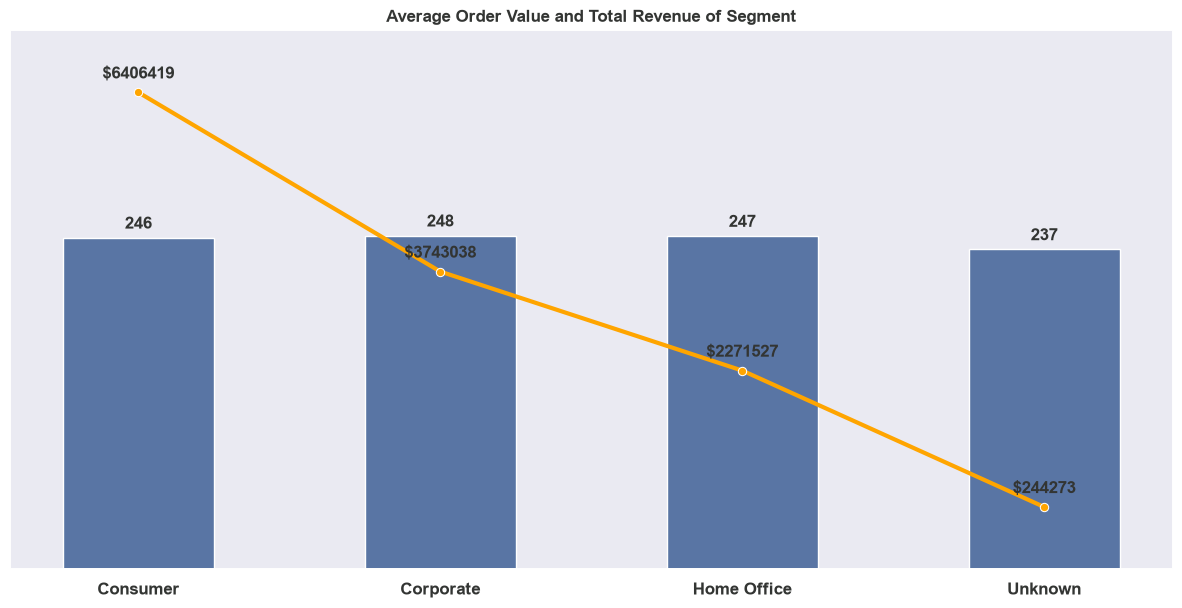

In [82]:
sns.set_theme()
fig, ax = plt.subplots(figsize=(15,7))

ax = sns.barplot(
    data=sales_and_orders_by_segment,
    x='Segment',
    y='avg_order_value',
    width=0.5
)
ax.grid(False)
ax.set_yticks([]) # remove the yticks
ax.set_yticklabels([]) # remove the yticklabels
ax.set_xlabel('') # remove the title of x-axis
ax.set_ylabel('') # remove the title of y-axis
ax.tick_params(axis='x', labelsize=12, labelcolor='#333533') # colorise the xticklabel
plt.setp(ax.get_xticklabels(), fontweight='bold') # set the fontweight to bold of xticklabels
ax.set_ylim(0,400) # set min and max of y-axis bin
ax.set_title('Average Order Value and Total Revenue of Segment', fontsize=12, fontweight='bold', color='#333533')

# =============== display values of bars ===============
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.00f}', fontsize=12, padding=4, fontweight='bold', color='#333533')

ax1 = ax.twinx()
ax1 = sns.lineplot(
    data=sales_and_orders_by_segment,
    x='Segment',
    y='total_revenue',
    color='orange',
    linewidth=3,
    marker='o'
)
ax1.grid(False)
ax1.set_ylabel('')
ax1.set_yticklabels([])
ax1.set_yticks([])

# =============== Add value labels above each point ===============
for x, y in zip(sales_and_orders_by_segment['Segment'], sales_and_orders_by_segment['total_revenue']):
    ax1.annotate(f'${y:.0f}', 
                xy=(x, y), 
                xytext=(0, 10),           # offset in points (x, y)
                textcoords='offset points',
                ha='center', 
                fontsize=12, 
                fontweight='bold',
                color='#333533'
                
                )
ax1.margins(y=0.15)  # not ax.margins() — ax is your bars, ax2 is your line

plt.show()

In [83]:
# Business Question 10:
# What is the Average Order Value (AOV) across the different customer Segments?

# Answer:
# Each category in Segments almost have the same AOV with ranging from around 240, and one group around 230. They only differ when it comes to
# total revenue. Consumer holds the highest sales with the amassing amount of around $6,4m while the lowest are only around $200k. Segments might be
# tied in AOV but in revenue, it shows the big difference.